In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import random
import time

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1775964495.232386 3217448 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775964495.873073 3217448 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
os.makedirs("figures", exist_ok=True)

pileups = np.load("pileup_waveforms.npz")
X_pileup_raw = pileups["pileup_wf"].astype(np.float32)   # (N, 104) raw voltage

y_1 = pileups["primary_label"]
y_2 = pileups["secondary_label"]
Y = np.column_stack([y_1, y_2]).astype(np.int32)         # (N, 2)

# --- L2 normalize each pileup waveform (per-waveform amplitude strip) ---
X_norms = np.linalg.norm(X_pileup_raw, axis=1)           # (N,) original norms
safe = np.where(X_norms == 0, 1.0, X_norms)
X_pileup = X_pileup_raw / safe[:, None]                  # (N, 104) L2-normed

# --- Train/test split; keep norms aligned so we can plot in raw volts later ---
X_train, X_test, Y_train, Y_test, norms_train, norms_test = train_test_split(
    X_pileup, Y, X_norms,
    test_size=0.2,
    random_state=42,
)

# --- Add channel dim for CNN models: (N, 104, 1) ---
X_train_n = X_train[..., None]
X_test_n  = X_test[..., None]

print(f"Train: {X_train_n.shape}   Test: {X_test_n.shape}")
print(f"L2 norm sanity check: train row-norms mean = {np.linalg.norm(X_train, axis=1).mean():.4f}")
print(f"Value range: [{X_train.min():.4f}, {X_train.max():.4f}]")

Train: (138669, 104, 1)   Test: (34668, 104, 1)
L2 norm sanity check: train row-norms mean = 1.0000
Value range: [-0.0335, 0.7232]


In [3]:
input_length = np.shape(X_train_n)[1]
latent_dim = 16 #artbitrary previously tried 8 with worse results

inputs = tf.keras.Input(shape=(input_length, 1))

#  Encoder 
x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2, padding='same')(x)   # 104 → 52

x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)   # 52 → 26

x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)   # 26 → 13

shape_before_flatten = x.shape[1:]  # (13, 128)

#bottleneck 
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, name="latent")(x)

#  Decoder 
x = layers.Dense(shape_before_flatten[0] * shape_before_flatten[1], activation='relu')(latent)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.UpSampling1D(2)(x)  # 13 → 26
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)  # 26 → 52
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)  # 52 → 104
x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

#  Classifier 
clf = layers.Dense(32, activation='relu')(latent)
clf = layers.Dense(16, activation='relu')(clf)
classification = layers.Dense(2, activation='sigmoid', name="classification")(clf)

#  Model (Encoder + classifier)
model = Model(inputs, [reconstruction, classification])

I0000 00:00:1775964497.042090 3217448 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1614 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "reconstruction": "mse",
        "classification": "binary_crossentropy"
    },
    loss_weights={
        "reconstruction": 1,
        "classification": 1
    },
    metrics={
        "classification": ["accuracy"]
    }
)

In [5]:
history = model.fit(
    X_train_n,
    {"reconstruction": X_train_n,
     "classification": Y_train},
    validation_data=(
        X_test_n,
        {"reconstruction": X_test_n,
         "classification": Y_test}
    ),
    epochs=50,
    batch_size=256,
)

Epoch 1/50


I0000 00:00:1775964498.660156 3217725 service.cc:153] XLA service 0x7a930c03bec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775964498.660168 3217725 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1775964498.691476 3217725 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775964498.936656 3217725 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1775964498.947475 3217725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4964__.49
I0000 00:00:1775964499.612811 3217854 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_36', 4 bytes spill stores, 4 bytes spill loads

E0000 00:00:1775964499.651099 3217866 cuda_timer.cc:87] Delay kernel timed ou

 63/542 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - classification_accuracy: 0.5067 - classification_loss: 0.6807 - loss: 0.6851 - reconstruction_loss: 0.0044

I0000 00:00:1775964511.782584 3217725 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


540/542 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - classification_accuracy: 0.5979 - classification_loss: 0.4730 - loss: 0.4744 - reconstruction_loss: 0.0014

I0000 00:00:1775964513.368792 3217715 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4964__.49
W0000 00:00:1775964523.748292 3218565 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.07GiB (rounded to 2220094208)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1775964523.748336 3218565 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1775964523.748338 3218565 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 67, Chunks in use: 66. 16.8KiB allocated for chunks. 16.5KiB in use in bin. 3.6KiB client-requested in use in bin.
I0000 00:00:1775964523.748342 3218565 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 13, Chunks in use: 12. 6.8KiB allocated for chunks. 6.0KiB in use in bin. 5.2KiB client-requested in use in bin.
I0000 0

542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - classification_accuracy: 0.5981 - classification_loss: 0.4726 - loss: 0.4740 - reconstruction_loss: 0.0014

I0000 00:00:1775964526.110146 3217718 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8889__.16
I0000 00:00:1775964526.732532 3217725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8889__.16


542/542 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - classification_accuracy: 0.6530 - classification_loss: 0.3567 - loss: 0.3573 - reconstruction_loss: 5.8329e-04 - val_classification_accuracy: 0.6893 - val_classification_loss: 0.2487 - val_loss: 0.2489 - val_reconstruction_loss: 1.9681e-04
Epoch 2/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_accuracy: 0.7163 - classification_loss: 0.2245 - loss: 0.2247 - reconstruction_loss: 1.6693e-04 - val_classification_accuracy: 0.7143 - val_classification_loss: 0.2032 - val_loss: 0.2035 - val_reconstruction_loss: 1.4523e-04
Epoch 3/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_accuracy: 0.7349 - classification_loss: 0.2019 - loss: 0.2021 - reconstruction_loss: 1.3963e-04 - val_classification_accuracy: 0.7405 - val_classification_loss: 0.1898 - val_loss: 0.1900 - val_reconstruction_loss: 2.0081e-04
Epoch 4/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - classification_accuracy: 0.7429 - classification_loss: 0.1883 - loss: 0.1

I0000 00:00:1775964601.124624 3217725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_211580__.7


1027/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step

I0000 00:00:1775964602.187345 3217710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_215145__.7
E0000 00:00:1775964602.386005 3226723 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775964602.522719 3226703 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


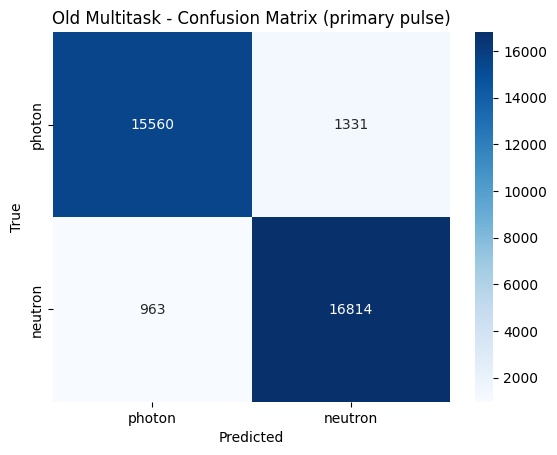

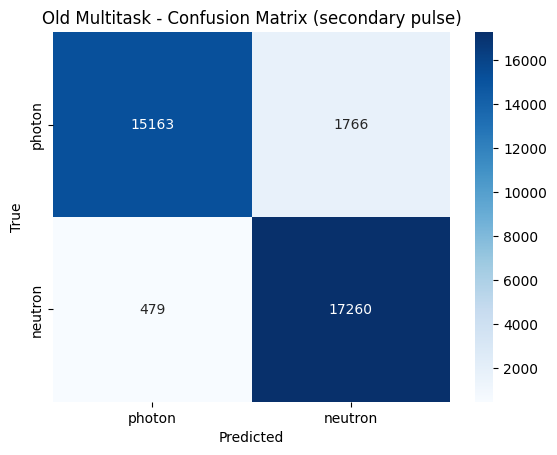

In [6]:
# Get predictions
y_pred = model.predict(X_test_n)[1]
y_pred_bin = (y_pred > 0.5).astype(int)

# Plot confusion matrix for each label (primary/secondary pulse type)
for i, name in enumerate(["primary", "secondary"]):
    cm = confusion_matrix(Y_test[:, i], y_pred_bin[:, i])
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["photon", "neutron"], yticklabels=["photon", "neutron"])
    plt.title(f"Old Multitask - Confusion Matrix ({name} pulse)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(f"figures/a2_multitask_old_confusion_matrix_{name}.png", dpi=120, bbox_inches="tight")
    plt.show()

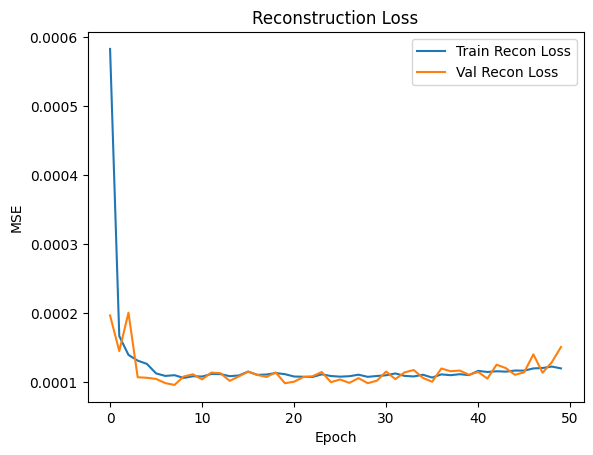

In [7]:
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig("figures/a2_multitask_old_reconstruction_loss.png", dpi=120, bbox_inches="tight")
plt.show()

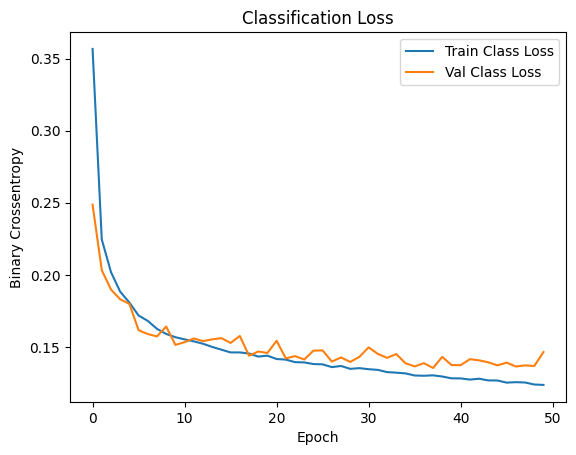

In [8]:
plt.figure()
plt.plot(history.history['classification_loss'], label='Train Class Loss')
plt.plot(history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.savefig("figures/a2_multitask_old_classification_loss.png", dpi=120, bbox_inches="tight")
plt.show()

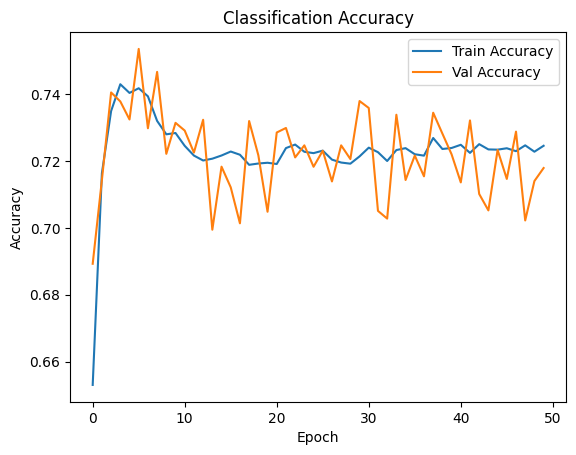

In [9]:
plt.figure()
plt.plot(history.history['classification_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_classification_accuracy'], label='Val Accuracy')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("figures/a2_multitask_old_classification_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
#Test without autoencoder

#Classifier only
inputs = tf.keras.Input(shape=(104,))
x = layers.Dense(32, activation="relu")(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(2, activation="sigmoid")(x)

base_model = Model(inputs, outputs)
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Baseline uses the 2D L2-normed data (drop the channel dim)
base_model_history = base_model.fit(
    X_train_n.squeeze(-1),
    Y_train,
    validation_data=(X_test_n.squeeze(-1), Y_test),
    epochs=50,
    batch_size=256,
)

Epoch 1/50


I0000 00:00:1775964603.985932 3217710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227425__.11


471/542 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - accuracy: 0.5576 - loss: 0.6073

I0000 00:00:1775964605.091126 3217727 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227425__.11


542/542 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5473 - loss: 0.5072 - val_accuracy: 0.5548 - val_loss: 0.3973
Epoch 2/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.6354 - loss: 0.3439 - val_accuracy: 0.6656 - val_loss: 0.3065
Epoch 3/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.6782 - loss: 0.2882 - val_accuracy: 0.6876 - val_loss: 0.2720
Epoch 4/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.6879 - loss: 0.2631 - val_accuracy: 0.6896 - val_loss: 0.2523
Epoch 5/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.6951 - loss: 0.2466 - val_accuracy: 0.6965 - val_loss: 0.2407
Epoch 6/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.6969 - loss: 0.2351 - val_accuracy: 0.6909 - val_loss: 0.2303
Epoch 7/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.6973 - loss: 0.2268 - val_accuracy: 0.6953 - val_loss: 0.2224
Epoch 8/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - accuracy: 0.6988 - loss: 0.2205 - val_accuracy:

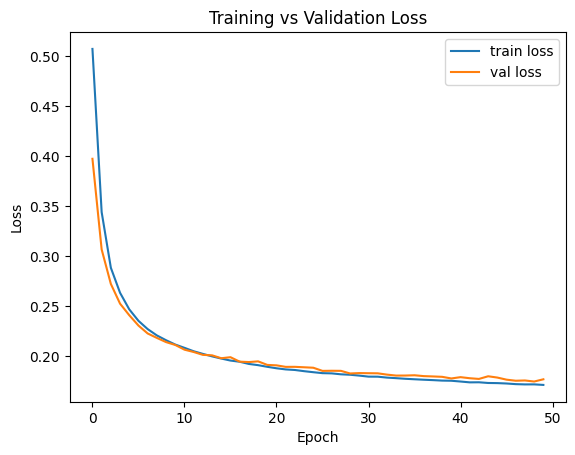

In [11]:
import matplotlib.pyplot as plt

plt.plot(base_model_history.history['loss'], label='train loss')
plt.plot(base_model_history.history['val_loss'], label='val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig("figures/a2_multitask_baseline_loss.png", dpi=120, bbox_inches="tight")
plt.show()

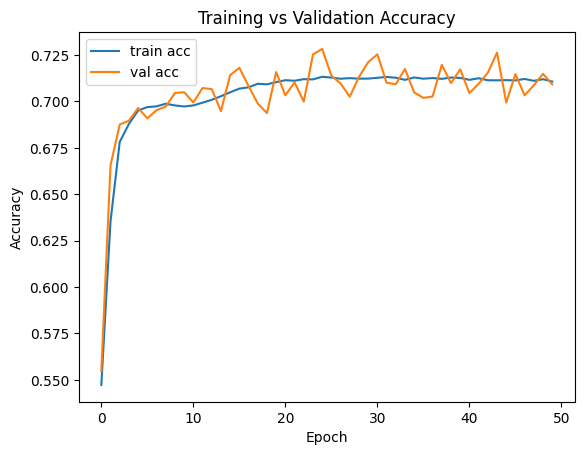

In [12]:
plt.plot(base_model_history.history["accuracy"], label="train acc")
plt.plot(base_model_history.history["val_accuracy"], label="val acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig("figures/a2_multitask_baseline_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

I0000 00:00:1775964629.783891 3217711 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 1s 642us/step


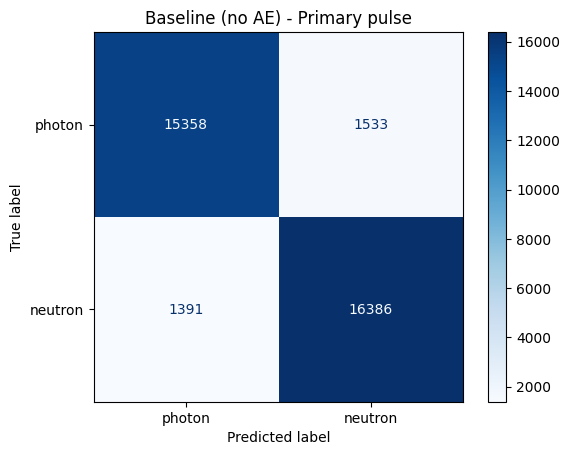

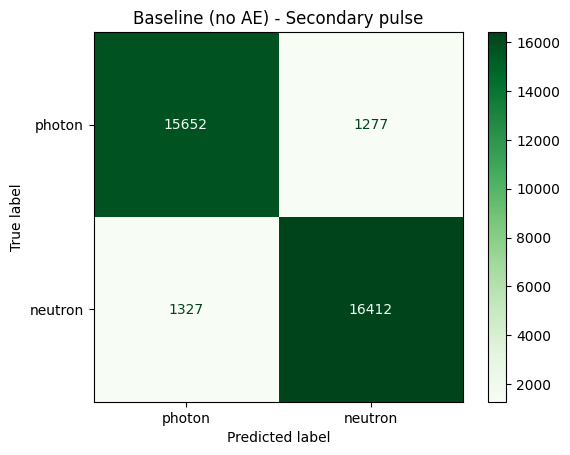

In [13]:
import numpy as np

y_pred_probs = base_model.predict(X_test_n.squeeze(-1))
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = Y_test.astype(int)

cm0 = confusion_matrix(y_true[:, 0], y_pred[:, 0])
disp0 = ConfusionMatrixDisplay(cm0, display_labels=["photon", "neutron"])
disp0.plot(cmap="Blues", values_format="d")
plt.title("Baseline (no AE) - Primary pulse")
plt.savefig("figures/a2_multitask_baseline_confusion_matrix_primary.png", dpi=120, bbox_inches="tight")
plt.show()

cm1 = confusion_matrix(y_true[:, 1], y_pred[:, 1])
disp1 = ConfusionMatrixDisplay(cm1, display_labels=["photon", "neutron"])
disp1.plot(cmap="Greens", values_format="d")
plt.title("Baseline (no AE) - Secondary pulse")
plt.savefig("figures/a2_multitask_baseline_confusion_matrix_secondary.png", dpi=120, bbox_inches="tight")
plt.show()

## Tuned CNN Autoencoder for pileups (from a2_tune.ipynb)

This uses the best CNN configuration found by the a2 pileup hyperparameter search.
When trained jointly with the classification head (as in this notebook), accuracy
should be significantly higher than the standalone logistic-regression evaluation
in a2_tune, because the latent space gets shaped by BOTH reconstruction and
classification gradients simultaneously.

**Tuned configuration (a2_tune rank 1 CNN, composite score 0.186):**

| Hyperparameter | Value |
|---|---|
| latent_dim | 32 |
| n_conv_layers | 2 (stride-2 Conv1D) |
| kernel_size | 3 |
| n_filters_start | 64 (constant → filters = [64, 64]) |
| activation | elu |
| output_activation | linear |
| dropout | 0.3 |
| l2_reg | 1e-5 |
| noise_std | 0.02 (denoising) |
| batch_norm | False |
| optimizer | Nadam |
| learning_rate | 1e-4 |
| batch_size | 256 |
| reconstruction loss | MSE |
| n_params | ~133k |

In [14]:
from tensorflow.keras import regularizers

input_length = np.shape(X_train_n)[1]
latent_dim_tuned = 32
l2_reg = regularizers.l2(1e-5)

tuned_inputs = tf.keras.Input(shape=(input_length, 1))

# Denoising: add slight Gaussian noise to input during training
x = layers.GaussianNoise(0.02)(tuned_inputs)

# Encoder: 2 stride-2 Conv1D layers, 64 filters each (constant), kernel 3, elu
x = layers.Conv1D(64, 3, strides=2, padding="same", kernel_regularizer=l2_reg)(x)
x = layers.Activation("elu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Conv1D(64, 3, strides=2, padding="same", kernel_regularizer=l2_reg)(x)
x = layers.Activation("elu")(x)
x = layers.Dropout(0.3)(x)

pre_flat_shape = x.shape[1:]          # (26, 64)
flat_size = int(pre_flat_shape[0] * pre_flat_shape[1])

# Latent bottleneck (32-dim)
x = layers.Flatten()(x)
tuned_latent = layers.Dense(latent_dim_tuned)(x)
tuned_latent = layers.Activation("elu", name="latent_tuned")(tuned_latent)

# Decoder: mirror encoder with Conv1DTranspose
x = layers.Dense(flat_size)(tuned_latent)
x = layers.Activation("elu")(x)
x = layers.Reshape(pre_flat_shape)(x)
x = layers.Conv1DTranspose(64, 3, strides=2, padding="same", kernel_regularizer=l2_reg)(x)
x = layers.Activation("elu")(x)
x = layers.Dropout(0.3)(x)
tuned_reconstruction = layers.Conv1DTranspose(
    1, 3, strides=2, padding="same", activation="linear", name="reconstruction"
)(x)

# Classifier: Dense 32 -> 16 -> 2 (primary + secondary composition)
clf = layers.Dense(32, activation="relu")(tuned_latent)
clf = layers.Dense(16, activation="relu")(clf)
tuned_classification = layers.Dense(2, activation="sigmoid", name="classification")(clf)

tuned_model = Model(tuned_inputs, [tuned_reconstruction, tuned_classification])

tuned_model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-4),
    loss={
        "reconstruction": "mse",
        "classification": "binary_crossentropy",
    },
    loss_weights={"reconstruction": 1.0, "classification": 1.0},
    metrics={"classification": ["accuracy"]},
)
tuned_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 104, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 104, 1)    │          0 │ input_layer_2[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 52, 64)    │        256 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 52, 64)    │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 52, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 26, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 26, 64)    │          0 │ conv1d_7[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 26, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1664)      │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │     53,280 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_tuned        │ (None, 32)        │          0 │ dense_6[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1664)      │     54,912 │ latent_tuned[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1664)      │          0 │ dense_7[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 26, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose    │ (None, 52, 64)    │     12,352 │ reshape_1[0][0]   │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 52, 64)    │          0 │ conv1d_transpose… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      1,056 │ latent_tuned[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 52, 64)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        528 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 104, 1)    │        193 │ dropout_2[0][0]   │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 134,963 (527.20 KB)

 Trainable params: 134,963 (527.20 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
tuned_history = tuned_model.fit(
    X_train_n,
    {"reconstruction": X_train_n,
     "classification": Y_train},
    validation_data=(
        X_test_n,
        {"reconstruction": X_test_n,
         "classification": Y_test}
    ),
    epochs=50,
    batch_size=256,
)

Epoch 1/50


I0000 00:00:1775964632.662661 3217710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_377443__.26
I0000 00:00:1775964632.732587 3217710 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


533/542 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - classification_accuracy: 0.5482 - classification_loss: 0.6407 - loss: 0.6461 - reconstruction_loss: 0.0041

I0000 00:00:1775964636.175002 3217715 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_377443__.26
I0000 00:00:1775964636.246924 3217715 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775964636.587612 3234105 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_34', 36 bytes spill stores, 36 bytes spill loads

I0000 00:00:1775964636.678237 3234100 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_34', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1775964636.706371 3234103 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_16', 8 bytes spill store

542/542 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - classification_accuracy: 0.5481 - classification_loss: 0.6397 - loss: 0.6451 - reconstruction_loss: 0.0041

I0000 00:00:1775964639.041892 3217715 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_381252__.14
I0000 00:00:1775964639.475204 3217727 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_381252__.14


542/542 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - classification_accuracy: 0.5419 - classification_loss: 0.5801 - loss: 0.5836 - reconstruction_loss: 0.0022 - val_classification_accuracy: 0.5550 - val_classification_loss: 0.4636 - val_loss: 0.4653 - val_reconstruction_loss: 5.0749e-04
Epoch 2/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - classification_accuracy: 0.5785 - classification_loss: 0.4882 - loss: 0.4902 - reconstruction_loss: 8.3671e-04 - val_classification_accuracy: 0.6106 - val_classification_loss: 0.4144 - val_loss: 0.4159 - val_reconstruction_loss: 4.0101e-04
Epoch 3/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - classification_accuracy: 0.6207 - classification_loss: 0.4531 - loss: 0.4548 - reconstruction_loss: 6.5743e-04 - val_classification_accuracy: 0.6625 - val_classification_loss: 0.3747 - val_loss: 0.3760 - val_reconstruction_loss: 3.1348e-04
Epoch 4/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - classification_accuracy: 0.6432 - classification_loss: 0.4252 - loss: 0.4268 - 

I0000 00:00:1775964680.221823 3217715 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_583797__.1


 935/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 376us/step

I0000 00:00:1775964681.050220 3217710 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_587224__.1


1084/1084 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step


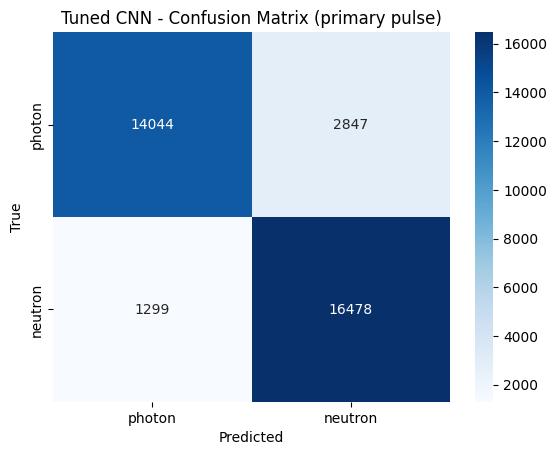

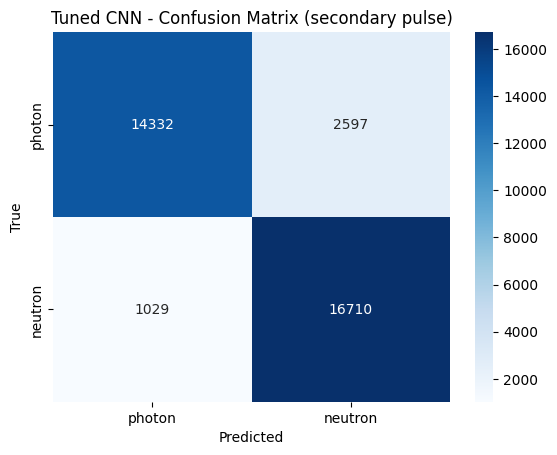

In [16]:
y_pred_tuned = tuned_model.predict(X_test_n)[1]
y_pred_tuned_bin = (y_pred_tuned > 0.5).astype(int)

for i, name in enumerate(["primary", "secondary"]):
    cm = confusion_matrix(Y_test[:, i], y_pred_tuned_bin[:, i])
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["photon", "neutron"], yticklabels=["photon", "neutron"])
    plt.title(f"Tuned CNN - Confusion Matrix ({name} pulse)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(f"figures/a2_multitask_tuned_confusion_matrix_{name}.png", dpi=120, bbox_inches="tight")
    plt.show()

## Before / After Comparison

Side-by-side figures comparing the hand-designed pileup autoencoder with the tuned CNN autoencoder.

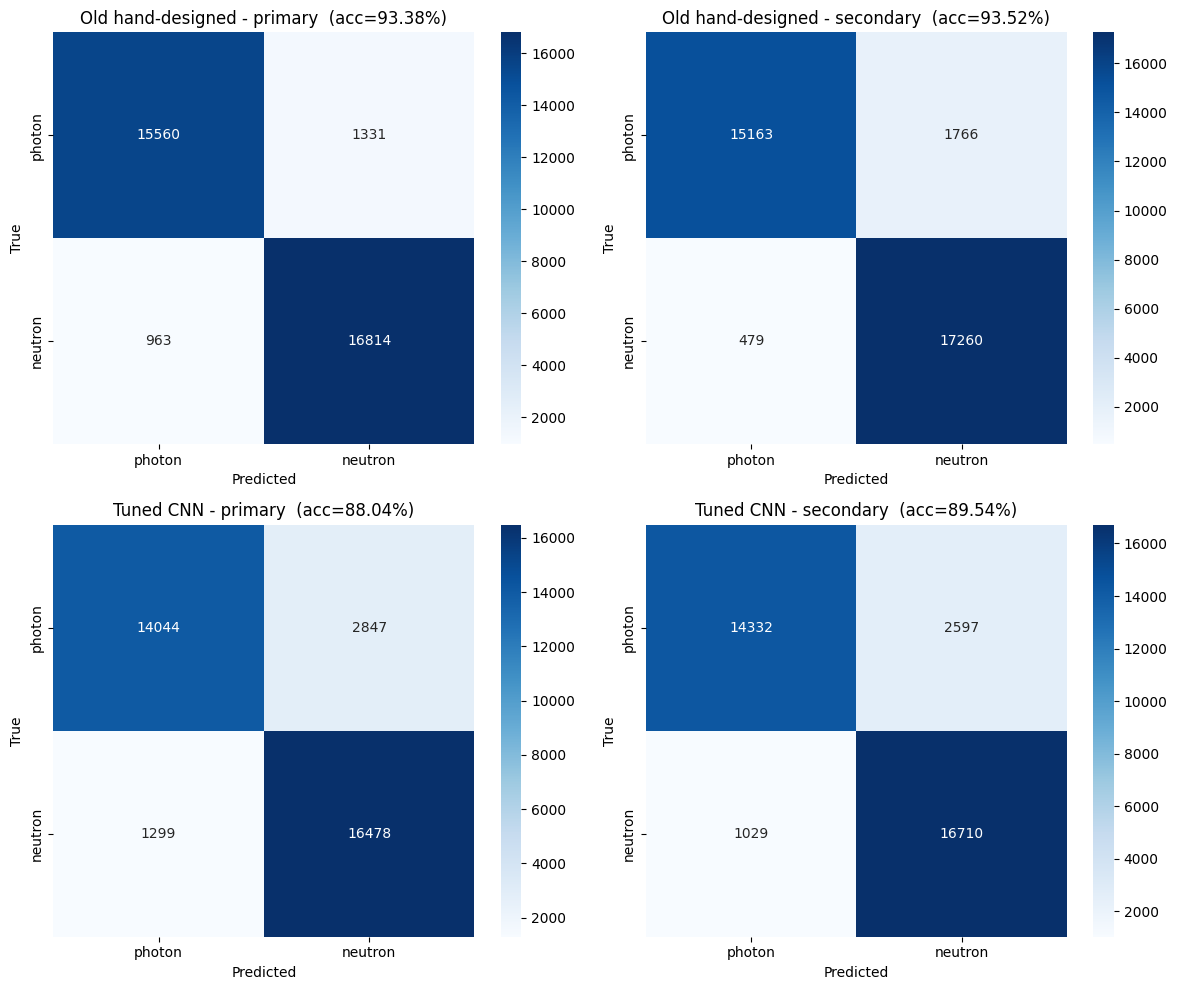

In [17]:
# 2x2 grid: rows = old vs tuned, cols = primary vs secondary
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_info = [
    ("Old hand-designed", y_pred_bin,       "Blues"),
    ("Tuned CNN",         y_pred_tuned_bin, "Blues"),
]

for row, (model_name, preds, cmap) in enumerate(models_info):
    for col, pulse_name in enumerate(["primary", "secondary"]):
        cm = confusion_matrix(Y_test[:, col], preds[:, col])
        acc = cm.diagonal().sum() / cm.sum()
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=axes[row, col],
                    xticklabels=["photon", "neutron"], yticklabels=["photon", "neutron"])
        axes[row, col].set_title(f"{model_name} - {pulse_name}  (acc={acc*100:.2f}%)")
        axes[row, col].set_xlabel("Predicted")
        axes[row, col].set_ylabel("True")

plt.tight_layout()
plt.savefig("figures/a2_multitask_compare_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

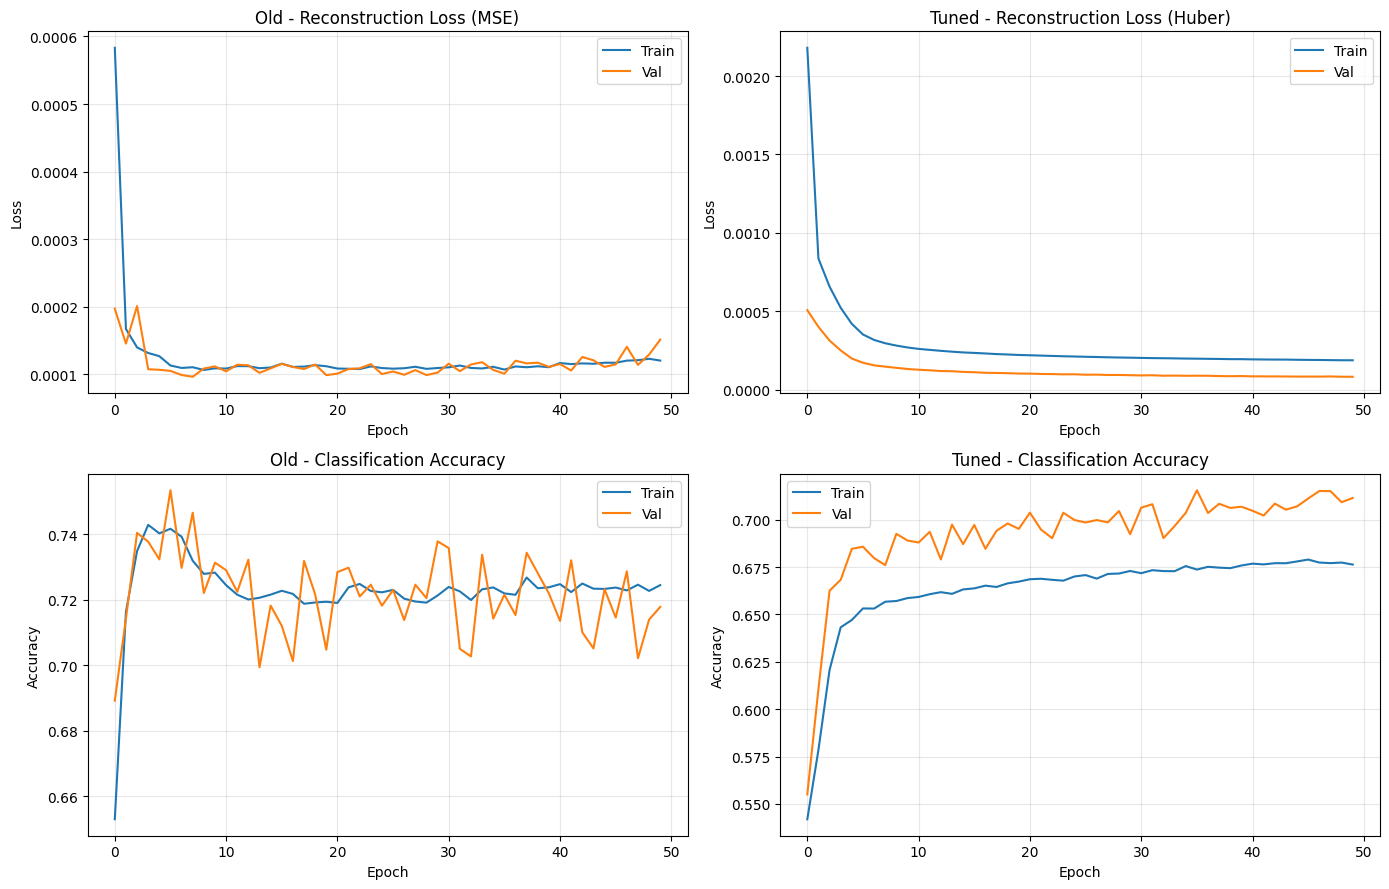

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Row 1: reconstruction loss
axes[0, 0].plot(history.history["reconstruction_loss"], label="Train")
axes[0, 0].plot(history.history["val_reconstruction_loss"], label="Val")
axes[0, 0].set_title("Old - Reconstruction Loss (MSE)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(tuned_history.history["reconstruction_loss"], label="Train")
axes[0, 1].plot(tuned_history.history["val_reconstruction_loss"], label="Val")
axes[0, 1].set_title("Tuned - Reconstruction Loss (Huber)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Row 2: classification accuracy
axes[1, 0].plot(history.history["classification_accuracy"], label="Train")
axes[1, 0].plot(history.history["val_classification_accuracy"], label="Val")
axes[1, 0].set_title("Old - Classification Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(tuned_history.history["classification_accuracy"], label="Train")
axes[1, 1].plot(tuned_history.history["val_classification_accuracy"], label="Val")
axes[1, 1].set_title("Tuned - Classification Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/a2_multitask_compare_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Reconstruction visualizations

Random test pileup waveforms reconstructed by each autoencoder. Black = original, blue = hand-designed, orange = tuned. Plots are in raw voltage units using the per-waveform L2 norms stored at preprocessing time.

I0000 00:00:1775964682.641106 3217725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_215145__.7
I0000 00:00:1775964683.174851 3217715 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_587224__.1


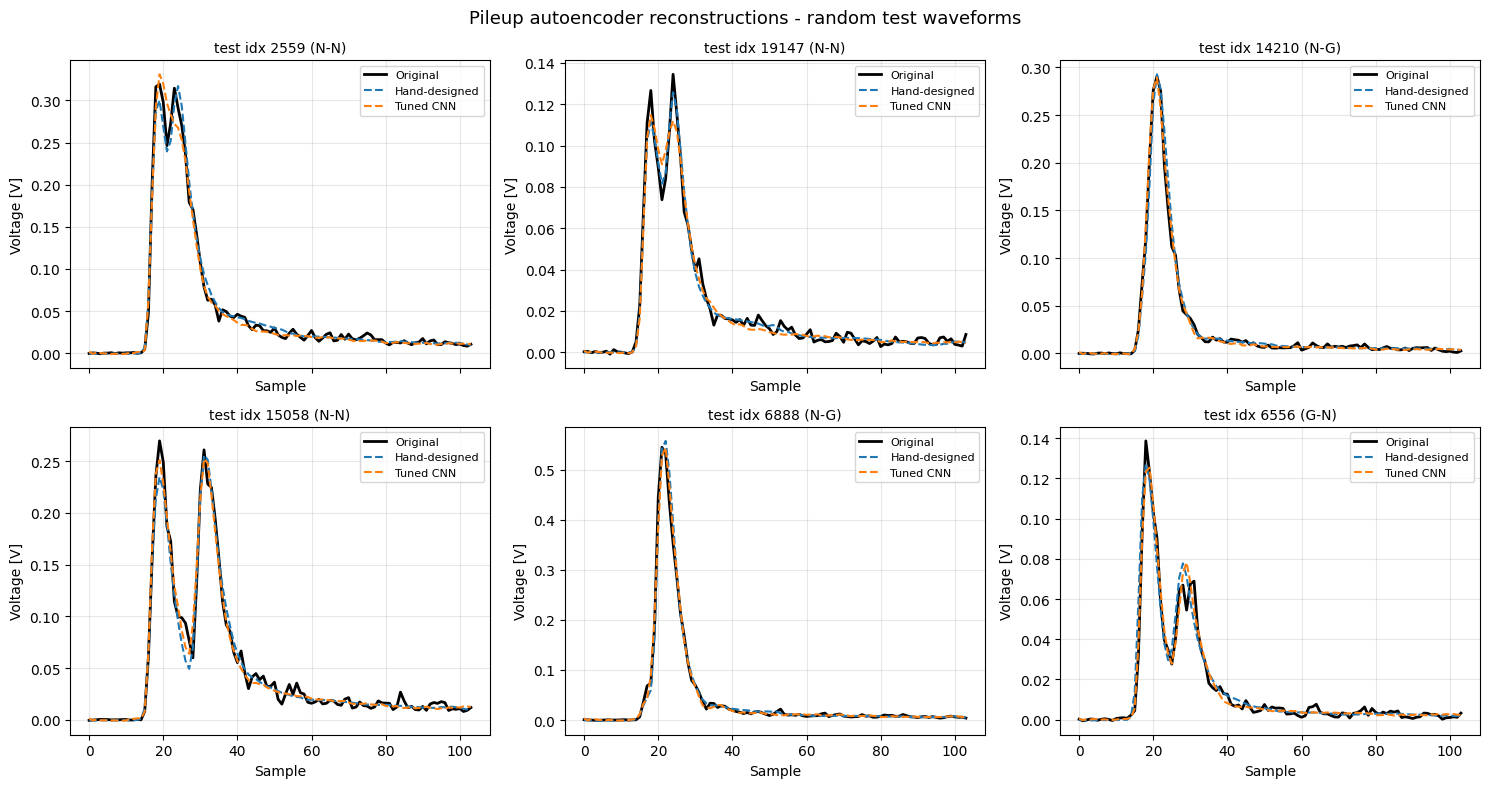

In [19]:
n_plot = 6
rng_plot = np.random.default_rng()
indices = rng_plot.choice(X_test_n.shape[0], size=n_plot, replace=False)

recon_old   = model.predict(X_test_n[indices], verbose=0)[0].squeeze(-1)
recon_tuned = tuned_model.predict(X_test_n[indices], verbose=0)[0].squeeze(-1)
orig_l2     = X_test_n[indices].squeeze(-1)

# Convert to raw voltage using stored L2 norms
sel_norms = norms_test[indices, None]
orig_show  = orig_l2     * sel_norms
old_show   = recon_old   * sel_norms
tuned_show = recon_tuned * sel_norms

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()
for ax, row, idx in zip(axes, range(n_plot), indices):
    ax.plot(orig_show[row],  label="Original",      lw=2.0, color="black")
    ax.plot(old_show[row],   label="Hand-designed", lw=1.5, linestyle="--", color="tab:blue")
    ax.plot(tuned_show[row], label="Tuned CNN",     lw=1.5, linestyle="--", color="tab:orange")
    # Label with primary/secondary composition
    p, s = Y_test[idx]
    lab = f"{'N' if p == 1 else 'G'}-{'N' if s == 1 else 'G'}"
    ax.set_title(f"test idx {idx} ({lab})", fontsize=10)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Voltage [V]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Pileup autoencoder reconstructions - random test waveforms", fontsize=13)
plt.tight_layout()
plt.savefig("figures/a2_multitask_reconstructions.png", dpi=120, bbox_inches="tight")
plt.show()